In [22]:

import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:

import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv('mnist_train.csv')
t = df.iloc[:, 0] # the labels column
x = df.iloc[:, 1:] # the pixels columns
x_train_val , x_test, y_train_val, y_test = train_test_split(x , t , test_size=0.20, random_state=42 , stratify=t)
# Adding stratify=y ensures the split isn't random in a way that accidentally leaves all the "9s" in the test set

x_train, x_val, y_train, y_val = train_test_split(x_train_val , y_train_val , test_size=0.25, random_state=42 , stratify=y_train_val)

#check the splitting done correctly
print(f"Training shapes: {x_train.shape , y_train.shape}")
print(f"Validation shapes: {x_val.shape , y_val.shape}")
print(f"Testing shapes: {x_test.shape , y_test.shape}")


x_train = x_train/255.0
x_val = x_val/255.0
x_test = x_test/255.0

# Convert to PyTorch tensors el pictures el kter htt2sm batches

train_features = torch.tensor(x_train.values , dtype=torch.float32)
train_labels = torch.tensor(y_train.values , dtype=torch.long)

train_dataset = TensorDataset(train_features, train_labels)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True  # Shuffle the training data 
                              )

val_features = torch.tensor(x_val.values , dtype=torch.float32)
val_labels = torch.tensor(y_val.values , dtype=torch.long)
val_dataset = TensorDataset(val_features, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=64)

test_features = torch.tensor(x_test.values , dtype=torch.float32)
test_labels = torch.tensor(y_test.values , dtype=torch.long)
test_dataset = TensorDataset(test_features, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=64)



Training shapes: ((36000, 784), (36000,))
Validation shapes: ((12000, 784), (12000,))
Testing shapes: ((12000, 784), (12000,))


In [24]:

class digit_recognition(nn.Module):
    def __init__(self):
        super().__init__()
        # 784 pixel input maps to 128 neuron  to 10 output (digits 0-9)
        # without sequential i have to define each layer separately and call each one to forward pass
        # 2 hidden layers
        self.model = nn.Sequential(
             nn.Linear(784 , 128 ), 
             nn.ReLU(),nn.Dropout(0.2), 
             nn.Linear(128 , 64),
             nn.ReLU(),nn.Dropout(0.2),
             nn.Linear(64 , 32 ),
             nn.ReLU(),
             nn.Linear(32 , 10)
             
         )
        self.loss_fn = nn.CrossEntropyLoss()
        #apply is built in method in torch that applies a function to every layer in the network
        self.apply(self._init_weights_)
         # Dropout layer with 20% dropout rate
    def _init_weights_(self , module):
        if isinstance(module , nn.Linear):
            nn.init.kaiming_normal_(module.weight , mode = 'fan_in' , nonlinearity='relu')
            if module.bias is not None:
             nn.init.zeros_(module.bias)
            
    def forward(self, x):
        return self.model(x)

    def training_step(self , train_dataloader, val_dataloader , epochs, lr = 0.01 ):
        #odel.parameters() contains:
        # Layer 1: Weights (784 x 128) and Biases (128)
        # Layer 2: Weights (128 x 64) and Biases (64)
        # Layer 3: Weights (64 x 32) and Biases (32)
        # Layer 4: Weights (32 x 10) and Biases (10)
    #optimizer = optim.SGD(model.parameters(), lr=0.01)
     
     #loss = nn.CrossEntropyLoss()
     optimizer = optim.SGD(self.parameters(), lr= lr)
     history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
     for epoch in range (epochs) :
         self.train()  # Set the model to training mode to enable droupout percentage
         #When a neural network trains, it tries to minimize loss on the training data.
         # If given enough capacity (layers, neurons), it can do this too well 
         # it starts memorizing specific training examples rather than learning general patterns.
         #Why Overfitting Happens: Co-adaptation
         #The deeper reason is something called co-adaptation. Neurons in a layer start to rely on each other in very specific ways.
         #Imagine neurons A, B, C working together:
         #Neuron A: detects a curve at top
         #Neuron B: detects a gap in middle  
         #Neuron C: always fires to "fix" A's mistakes

         #→ C never learns anything useful on its own
         #→ The trio only works as a unit
         #→ Remove any one of them → whole prediction collapses
         running_loss = 0.0 
         correct_predictions = 0
         total_predictions = 0
         
         for pixels , labels in train_dataloader :
                optimizer.zero_grad()  
                y_hat = self(pixels)  #foward pass
                current_loss = self.loss_fn(y_hat, labels) #compute  training loss
                # this loss is average loss across the batch size 
                current_loss.backward()    # Backpropagation to compute gradients
                optimizer.step()   # Update the weights (Gradient Descent)
                #if current_loss.item() < threshold:
                 #   print(f"Early stopping at epoch {epoch} with loss {current_loss.item()}")
                  #  return
                running_loss += current_loss.item() * labels.size(0)  # Accumulate total loss for whole batch
                #as batches size are not always equal so we need
                #to multiply the average loss by the batch size to get the total loss for that batch
        
              #If you are training a model to recognize digits (0-9), 
              # the output layer has 10 neurons. Each neuron represents one digit.
              # For a single image, the output (y_hat) is a vector of 10 numbers:
              # $$y_{hat} = [ -1.2,  0.5, 6.2, -0.3,  0.1,  0.8,  -2.1,  1.1, 0.0,  -0.5 ]
              # $$The first number (-1.2) corresponds to class 0.
              # The second number (0.5) corresponds to class 1.
              # The third number (6.2) corresponds to class 2 and so on 
              # so y hat will be 10 dimension as 10 neurons in o/p layer * number of images in batch
                predections = y_hat.argmax(dim=1)
                correct_predictions+= (predections==labels).sum().item()
                # assume corrct labels [ 2  3 ,6 ] for 3 images batch
                # and the predections are [ 2  1 ,6 ]
                # what.sum() do is to count how many times the predections are equal to the  labels
                #treating true = 1 [true , false , true ]=> 2  correct predictions
                total_predictions += labels.size(0)  # Total number of predictions made
                #as you may ask yourself why labels.size(0) arenot labels.size() 1 dimension
                #bec it returns object of type tensor and we need to specify the dimension to get integer
         train_loss  = running_loss / total_predictions
         train_accuracy = correct_predictions / total_predictions
         self.eval()
         val_loss_sum, val_correct, val_total = 0.0, 0, 0
 
         with torch.no_grad():                  
            for pixels, labels in val_dataloader:
                y_hat = self(pixels)
                loss  = self.loss_fn(y_hat, labels)
 
                val_loss_sum += loss.item() * labels.size(0)
                preds         = y_hat.argmax(dim=1)
                val_correct  += (preds == labels).sum().item()
                val_total    += labels.size(0)
 
            val_loss = val_loss_sum / val_total
            val_acc  = val_correct  / val_total
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_accuracy)
            history["val_acc"].append(val_acc)
 
            print(f"Epoch {epoch:>2}/{epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_accuracy:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")
 
     return history

Epoch  0/10 | Train Loss: 1.3456  Acc: 0.5611 | Val Loss: 0.5692  Acc: 0.8472
Epoch  1/10 | Train Loss: 0.6330  Acc: 0.8052 | Val Loss: 0.3941  Acc: 0.8888
Epoch  2/10 | Train Loss: 0.4922  Acc: 0.8512 | Val Loss: 0.3335  Acc: 0.9044
Epoch  3/10 | Train Loss: 0.4198  Acc: 0.8731 | Val Loss: 0.2917  Acc: 0.9154
Epoch  4/10 | Train Loss: 0.3751  Acc: 0.8859 | Val Loss: 0.2677  Acc: 0.9207
Epoch  5/10 | Train Loss: 0.3477  Acc: 0.8966 | Val Loss: 0.2494  Acc: 0.9249
Epoch  6/10 | Train Loss: 0.3191  Acc: 0.9061 | Val Loss: 0.2332  Acc: 0.9304
Epoch  7/10 | Train Loss: 0.2970  Acc: 0.9109 | Val Loss: 0.2219  Acc: 0.9341
Epoch  8/10 | Train Loss: 0.2824  Acc: 0.9145 | Val Loss: 0.2079  Acc: 0.9369
Epoch  9/10 | Train Loss: 0.2605  Acc: 0.9228 | Val Loss: 0.1991  Acc: 0.9421


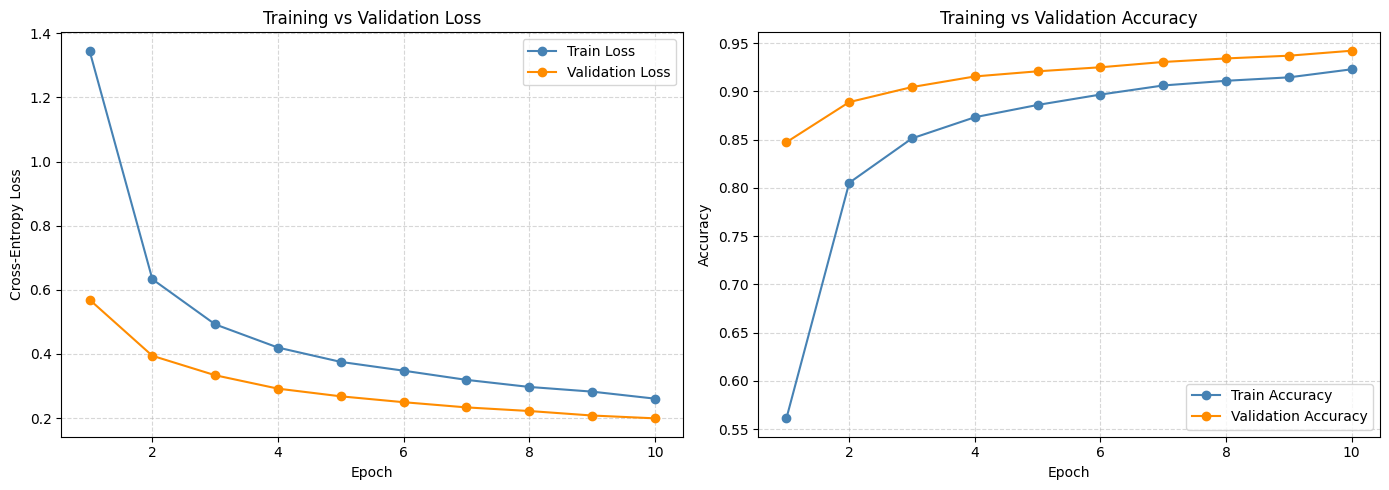

Plot saved → training_curves.png


In [ ]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    # — Loss plot —
    ax1.plot(epochs, history["train_loss"], label="Train Loss",      color="steelblue",  marker="o")
    ax1.plot(epochs, history["val_loss"],   label="Validation Loss", color="darkorange", marker="o")
    ax1.set_title("Training vs Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)
 
    # — Accuracy plot —
    ax2.plot(epochs, history["train_acc"], label="Train Accuracy",      color="steelblue",  marker="o")
    ax2.plot(epochs, history["val_acc"],   label="Validation Accuracy", color="darkorange", marker="o")
    ax2.set_title("Training vs Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.5)
 
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Plot saved → training_curves.png")
 
 
# ─────────────────────────────────────────────
# 6. RUN EVERYTHING
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model   = digit_recognition()
    history = model.training_step( train_dataloader, val_dataloader, epochs=10, lr=0.01)
    plot_history(history)


#Imagine you have 1,000 images and a Batch Size of 100.
#To complete 1 Epoch, the model needs to process 10 Batches.
#This means 1 Epoch = 10 Iterations.